Loaded: (43405, 67)
Default rate: 0.0482
Features : 64
Samples  : 43,405
Positive : 2,091  (4.82%)
OOF ROC-AUC : 0.7782
OOF Brier   : 0.1888

Pd distribution:
count    43405.0000
mean         0.3957
std          0.2061
min          0.0000
25%          0.2499
50%          0.3799
75%          0.5159
max          1.0000
dtype: float64

Model saved: models/logistic/system_logistic.pkl
Quantile-based grade cut-offs:


,grade,pd_lower,pd_upper
0,AAA,0.000000,0.141822
1,AA,0.141822,0.219368
2,A,0.219368,0.306464
3,BBB,0.306464,0.405411
4,BB,0.405411,0.516200
5,B,0.516200,0.673042
6,CCC,0.673042,0.999993



System grade distribution:
system_grade
AAA    4341
AA     4340
A      6511
BBB    8681
BB     8680
B      6511
CCC    4341
Name: count, dtype: int64


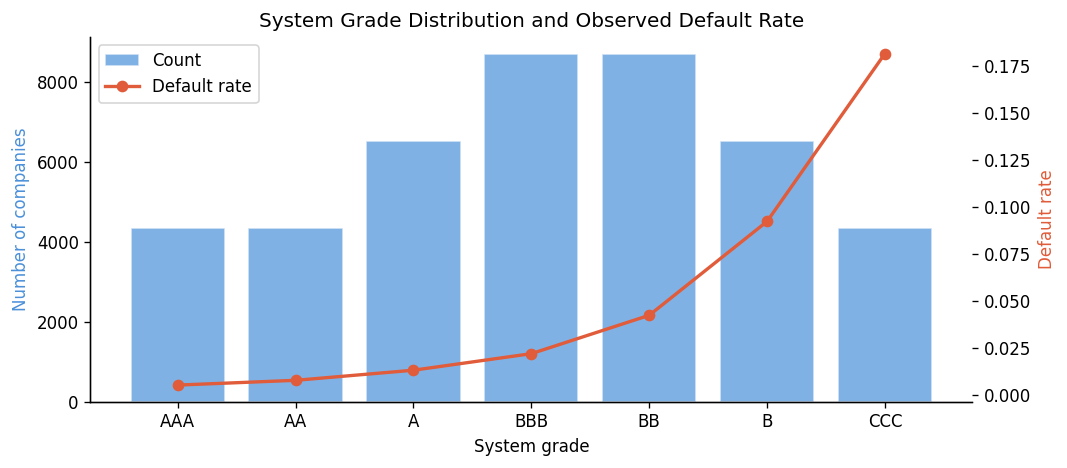

Figure saved: 05_system_grade_distribution.png
Grade-level default rate:


,n,default_rate
system_grade,,
AAA,4341,0.0053
AA,4340,0.0078
A,6511,0.0132
BBB,8681,0.0220
BB,8680,0.0424
B,6511,0.0923
CCC,4341,0.1815


Saved: ../results/tables/03_grade_default_rate.csv
Monotone default rate (AAA→CCC): True
Saved : ../data/processed/graded_data.parquet
Shape : (43405, 70)

New columns added:
          pd_system  grade_ordinal
count  4.340500e+04   43405.000000
mean   3.964487e-01       3.150006
std    2.055919e-01       1.768541
min    1.341648e-08       0.000000
25%    2.509054e-01       2.000000
50%    3.809460e-01       3.000000
75%    5.161999e-01       5.000000
max    9.999931e-01       6.000000


In [4]:
# NB03_grade_assignment.ipynb

# %% [markdown]
# # NB03 – System Grade Assignment
# **Purpose:** Train a logistic regression on financial variables to produce
# a predicted probability of default (Pd). Map Pd onto a credit rating scale
# (AAA → CCC) to simulate the *system model* grade.
#
# Note: Grade cut-offs are derived from the empirical Pd distribution
# (quantile-based) to ensure meaningful grade separation on this dataset.
#
# **Input:**  `data/processed/polish_master.parquet`
# **Output:**
# - `data/processed/graded_data.parquet`
# - `models/logistic/system_logistic.pkl`
# - `results/figures/05_system_grade_distribution.png`
# - `results/tables/03_grade_default_rate.csv`
# - `results/tables/03b_grade_cutoffs.csv`

# %%
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, brier_score_loss

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

PROC_DIR  = "../data/processed/"
MODEL_DIR = "../models/logistic/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(MODEL_DIR, exist_ok=True)

master = pd.read_parquet(PROC_DIR + "polish_master.parquet")
print(f"Loaded: {master.shape}")
print(f"Default rate: {master['default'].mean():.4f}")

# %% [markdown]
# ## 1. Feature matrix

# %%
EXCLUDE_COLS = {"default", "year_horizon", "class", "attr37_missing"}

FEATURE_COLS = [
    c for c in master.columns
    if c not in EXCLUDE_COLS
    and master[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

X = master[FEATURE_COLS].fillna(0)
y = master["default"]

print(f"Features : {len(FEATURE_COLS)}")
print(f"Samples  : {len(X):,}")
print(f"Positive : {y.sum():,}  ({y.mean():.2%})")

# %% [markdown]
# ## 2. Logistic regression (system model)
# 5-fold stratified cross-validation to get unbiased out-of-fold Pd estimates.

# %%
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C            = 0.1,
        max_iter     = 1000,
        class_weight = "balanced",
        solver       = "lbfgs",
        random_state = 42,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

print(f"OOF ROC-AUC : {roc_auc_score(y, oof_proba):.4f}")
print(f"OOF Brier   : {brier_score_loss(y, oof_proba):.4f}")
print(f"\nPd distribution:")
print(pd.Series(oof_proba).describe().round(4))

pipe.fit(X, y)
joblib.dump({"model": pipe, "feature_cols": FEATURE_COLS},
            MODEL_DIR + "system_logistic.pkl")
print("\nModel saved: models/logistic/system_logistic.pkl")

# %% [markdown]
# ## 3. Quantile-based Pd → Grade mapping
# Cut-offs derived from the empirical Pd distribution of this dataset.
# Grade proportions approximate real-world rating agency distributions:
# AAA~A (top 10%), BBB (next 15%), BB (next 20%), B (next 25%), CCC (bottom 30%).

# %%
pd_values = pipe.predict_proba(X)[:, 1]

# Quantile cut-offs (ascending Pd = descending creditworthiness)
quantile_cuts = [0.00, 0.10, 0.20, 0.35, 0.55, 0.75, 0.90, 1.00]
cutoffs = np.quantile(pd_values, quantile_cuts)

GRADE_LABELS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
GRADE_ORDER  = {g: i for i, g in enumerate(GRADE_LABELS)}

# Build cut-off table for reporting
cutoff_df = pd.DataFrame({
    "grade"    : GRADE_LABELS,
    "pd_lower" : cutoffs[:-1].round(6),
    "pd_upper" : cutoffs[1:].round(6),
})
print("Quantile-based grade cut-offs:")
display(cutoff_df)
cutoff_df.to_csv(TABLE_DIR + "03b_grade_cutoffs.csv", index=False)

def pd_to_grade(pd_val: float) -> str:
    """Map Pd to credit grade using quantile-based cut-offs."""
    for grade, lo, hi in zip(GRADE_LABELS, cutoffs[:-1], cutoffs[1:]):
        if lo <= pd_val < hi:
            return grade
    return "CCC"

master["pd_system"]     = pd_values
master["system_grade"]  = master["pd_system"].apply(pd_to_grade)
master["grade_ordinal"] = master["system_grade"].map(GRADE_ORDER)

print("\nSystem grade distribution:")
print(master["system_grade"].value_counts().reindex(GRADE_LABELS))

# %% [markdown]
# ## 4. Grade distribution & default rate chart

# %%
grade_stats = (
    master.groupby("system_grade")["default"]
          .agg(n="count", default_rate="mean")
          .reindex(GRADE_LABELS)
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(grade_stats.index, grade_stats["n"],
        color="#4A90D9", alpha=0.7, label="Count", edgecolor="white")
ax2.plot(grade_stats.index, grade_stats["default_rate"],
         "o-", color="#E05C3A", linewidth=2, label="Default rate", zorder=5)

ax1.set_xlabel("System grade")
ax1.set_ylabel("Number of companies", color="#4A90D9")
ax2.set_ylabel("Default rate", color="#E05C3A")
ax1.set_title("System Grade Distribution and Observed Default Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR + "05_system_grade_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: 05_system_grade_distribution.png")

# %% [markdown]
# ## 5. Grade-level default rate table

# %%
grade_table = grade_stats.copy()
grade_table["default_rate"] = grade_table["default_rate"].round(4)
grade_table.to_csv(TABLE_DIR + "03_grade_default_rate.csv")

print("Grade-level default rate:")
display(grade_table)
print(f"Saved: {TABLE_DIR}03_grade_default_rate.csv")

# %% [markdown]
# ## 6. Validate monotonicity
# Default rate should increase monotonically from AAA → CCC.

# %%
rates = grade_table["default_rate"].values
is_monotone = all(rates[i] <= rates[i+1] for i in range(len(rates)-1))
print(f"Monotone default rate (AAA→CCC): {is_monotone}")
if not is_monotone:
    print("  Warning: non-monotone grades detected – consider adjusting quantile_cuts.")

# %% [markdown]
# ## 7. Save graded dataset

# %%
out_path = PROC_DIR + "graded_data.parquet"
master.to_parquet(out_path, index=False)

print(f"Saved : {out_path}")
print(f"Shape : {master.shape}")
print("\nNew columns added:")
print(master[["pd_system", "system_grade", "grade_ordinal"]].describe())